# Phonon dispersion quick looking


No labels provided in QPOINTS file
No labels provided in QPOINTS file
No labels provided in QPOINTS file


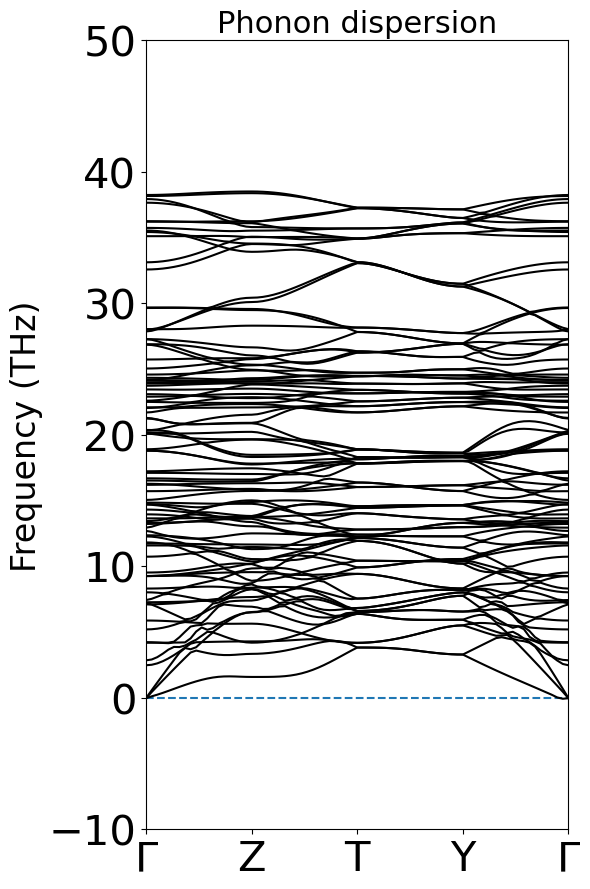

: 

In [ ]:
####Phonon Custom Script####
#Plots the phonon dispersion when LPHON_DISPERSION = .TRUE.

import matplotlib.pyplot as plt
import numpy as np

qpath = "./QPOINTS"
file_path = "./OUTCAR"


#Read the QPOINTS file to extract the path sampling and path labels
QPNTS = open(qpath,'r')
LINES = QPNTS.readlines()
POINTS = int(LINES[1])
my_xticks = []
xtick_pos = []
for i in range(4,len(LINES)):
    try:
        LINE = LINES[i].split()
        LABEL = LINE[3]
        DIST = [float(LINE[0]),float(LINE[1]),float(LINE[2])]
    except IndexError:
        print("No labels provided in QPOINTS file")
        quit()
    if(LABEL not in my_xticks):
        my_xticks.append(LABEL)
        xtick_pos.append(DIST)
         
    if(i==len(LINES)-1 and len(my_xticks)>2):
        my_xticks.append(LABEL)
        xtick_pos.append(DIST)

xtick_dist = []
for i in range(len(xtick_pos)):
    if (i == 0):
        xtick_dist.append(0)
    if(i > 0):
        POS1 = xtick_pos[i-1]
        POS2 = xtick_pos[i]
        D = np.sqrt((POS1[0]-POS2[0])**2 + (POS1[1]-POS2[1])**2 + (POS1[2]-POS2[2])**2)
        xtick_dist.append(xtick_dist[i-1]+D)
    


#Extract the THz phonon frequencies from the OUTCAR file
OUTCAR = open(file_path,"r")
READ = False
BAND = 0
NULL = 0
MAXBAND = 0
COUNT = False

while NULL < 20:

    LINE = OUTCAR.readline()

    if(LINE == "" or LINE == "\n"):
        NULL += 1
    else:
        NULL = 0

    if(LINE.strip() == "" and COUNT == True):
        break
    
    if("branch index" in LINE):
        COUNT = True
    
    if(COUNT == True and "branch index" not in LINE):
        MAXBAND +=1
OUTCAR.close()


OUTCAR = open(file_path,"r")
PATH = []
DISP = [[] for i in range(MAXBAND)]
PREV_POS = [0,0,0]

while NULL < 20:

    LINE = OUTCAR.readline()

    if(LINE == "" or LINE == "\n"):
        NULL += 1
    else:
        NULL = 0
    
    if("q-point No." in LINE):
        READ = False
        LINE = OUTCAR.readline().split()
        POS = [float(LINE[1]),float(LINE[2]),float(LINE[3])]
        DIST = np.sqrt((POS[0]-PREV_POS[0])**2 + (POS[1]-PREV_POS[1])**2 + (POS[2]-PREV_POS[2])**2)
        try:
            PATH.append(PATH[-1]+DIST)
        except IndexError:
            PATH.append(DIST)
        PREV_POS = POS 

    
    if("branch index" in LINE):
        READ = True
        BAND = 0
        LINE = OUTCAR.readline()
    
    if(READ==True and BAND<MAXBAND):
        LINE = LINE.split()
        DISP[BAND].append(float(LINE[1]))
        BAND += 1

#Generate the phonon dispersion plot
fig = plt.figure(figsize=(6,9))
for BND in DISP:
    plt.plot(PATH,BND,'k')
    plt.xticks(xtick_dist, my_xticks,fontsize = 30)
    plt.yticks(fontsize = 30)

plt.axhline(y=0,xmin=0,xmax=1,linestyle="--",zorder=0)
plt.ylabel("Frequency (THz)",fontsize=24)
plt.title("Phonon dispersion",fontsize=22)
plt.ylim(-10,50)
plt.xlim(xtick_dist[0],xtick_dist[-1])
plt.tight_layout()
#plt.show()
#plt.savefig(./Phonons.pdf",format="pdf",dpi = 300)
